# Label-Scarce *Where-to-Gate*: SAE absorber handle vs labeled dense gate

**Artifact `art_-zywGLxOcKOw` (iter-9, experiment M1'''').**

Single SAE latents are unreliable units of analysis (feature absorption / splitting / non-atomicity).
This experiment asks a concrete, decisive question about one *cluster-level* SAE handle — the **absorber latent**
that silently captures a sub-concept that its parent feature drops:

> At **full** sub-concept labels, a *genuinely-fair* conditional-dense gate
> (`DENSE-SUB-ABL-GATED-FAIR`: erase the labeled direction `u_sub` **only where** a precise logistic detector `d_sub`
> fires, β ≤ 1) **matches** the **label-free** single SAE absorber handle (`KG-ABL`).
> So the only remaining SAE-specific value is **label-free *where*-to-gate discovery**. Does that match **survive label
> scarcity**?

We vary `n` = number of sub-context labels used to fit **both** `u_sub(n)` and `d_sub(n)` over `{0, 1, 5, 20, full}` and
compare the labeled dense gate against the **n-independent** label-free SAE handle on two arms:

* **Arm 1 — Localization** (`$0`, deterministic): gate **balanced accuracy** on a *frozen disjoint* eval fold.
* **Arm 2 — Edit** (2 LLM judges): preservation / forget quality at matched behavioral forget. The **primary** metric is
  `adv_pres` = paired-bootstrap preservation difference (KG − dense).

### What this notebook does
The full pipeline needs a GPU, `gemma-2-2b` + a Gemma-Scope SAE, and two OpenRouter judges (not runnable in a
10-minute Colab session). Instead this demo loads the **pre-computed results** and **re-runs the analysis** that turns
them into the paper's verdict — using the **exact statistics functions copied verbatim from the engine**:

1. parse + tabulate the localization balanced-accuracy curve (SAE flat handle vs dense gate at each `n`);
2. plot it (the headline: dense **collapses at n=1**, recovers by n=5/20, matches at full);
3. **re-compute the primary edit metric `adv_pres`** live, from the raw per-prompt judge scores, with the verbatim
   `harmonic_mean` + `paired_bootstrap_diff`;
4. reproduce the overall fork verdict, `n_breakeven`, labeling-cost-saved, and the honest caveat.

**Verdict reproduced: `DEMONSTRATED_WHERE_TO_GATE_VALUE`.**

In [1]:
# --- Dependencies -------------------------------------------------------------
# This demo only needs numpy + matplotlib (we analyse pre-computed results, no GPU/model needed).
# Both are pre-installed on Colab -> install locally only, at Colab's exact versions (see aii-colab skill).
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *a])

if "google.colab" not in sys.modules:
    _pip("numpy==2.0.2", "matplotlib==3.10.0")


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports (trimmed from the original label_scarce.py import block + matplotlib) ---
import os, json, math, time
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# --- Data loading: GitHub URL (Colab) with local fallback (running here, before deploy) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-9/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
meta = data["metadata"]
print("experiment      :", meta["experiment"])
print("model / SAE     :", meta["model"], "|", meta["sae"]["release"], meta["sae"]["sae_params"])
print("overall verdict :", meta["overall_fork_verdict"])
print("datasets        :", [(d["dataset"], len(d["examples"])) for d in data["datasets"]])

experiment      : M1prime4_label_scarce_where_to_gate
model / SAE     : google/gemma-2-2b | google/gemma-scope-2b-pt-res layer_12/width_16k/average_l0_82
overall verdict : DEMONSTRATED_WHERE_TO_GATE_VALUE
datasets        : [('label_scarce_curve', 43), ('edit_per_prompt', 96)]


In [5]:
# =========================== CONFIG (tunable) ===========================
# Start at small/safe demo values; comment shows the original full-run value.
SEED   = 1234                       # original engine seed
B_BOOT = 10000                      # bootstrap resamples for CIs (original engine value; cheap on small arrays)
# B_BOOT = 2000                     # <-- smaller/faster value if you want a quicker pass

N_GRID = [0, 1, 5, 20, "full"]      # label budgets compared (n sub-context labels)
PRES   = ("RETAIN", "UNRELATED")    # preservation roles used by the primary edit metric adv_pres
DEMO_EDIT_CASE = "first_letter_large"   # case whose per-prompt judge scores are in the mini data

rng = np.random.default_rng(SEED)   # module-level rng used by the bootstrap functions below
print("config:", dict(SEED=SEED, B_BOOT=B_BOOT, N_GRID=N_GRID, PRES=PRES, DEMO_EDIT_CASE=DEMO_EDIT_CASE))

config: {'SEED': 1234, 'B_BOOT': 10000, 'N_GRID': [0, 1, 5, 20, 'full'], 'PRES': ('RETAIN', 'UNRELATED'), 'DEMO_EDIT_CASE': 'first_letter_large'}


## 1. Statistics helpers — copied **verbatim** from the engine

These three functions are taken unchanged from the iter-4..8 engine (`core.py` / `method.py`). They are the *exact*
estimators the original driver uses, so the numbers we recompute below are produced by the same code that produced the
published results.

* `harmonic_mean(f, c)` — joins judge fluency `f` and content-preservation `c` into one preservation score.
* `paired_bootstrap_diff(a, b)` — paired percentile bootstrap of `mean(a) − mean(b)`; `excl_0` flags a CI that excludes 0.
* `bootstrap_mean_ci(values)` — percentile bootstrap CI of a mean (provided for completeness).

In [6]:
# --- VERBATIM from method.py ---
def harmonic_mean(f, c):
    f = float(f); c = float(c)
    if f <= 0 and c <= 0:
        return 0.0
    return (2.0 * f * c) / (f + c + 1e-9)

# --- VERBATIM from core.py ---
def paired_bootstrap_diff(a, b, B=B_BOOT):
    a = np.asarray(a, float); b = np.asarray(b, float)
    n = len(a)
    if n == 0:
        return {"diff": 0.0, "ci_lo": 0.0, "ci_hi": 0.0, "excl_0": False, "n": 0}
    idx = rng.integers(0, n, size=(B, n))
    d = a[idx].mean(1) - b[idx].mean(1)
    lo, hi = np.percentile(d, [2.5, 97.5])
    return {"diff": float(a.mean() - b.mean()), "ci_lo": float(lo), "ci_hi": float(hi),
            "excl_0": bool(lo > 0 or hi < 0), "n": int(n)}

def bootstrap_mean_ci(values, B=B_BOOT):
    v = np.asarray(values, float); n = len(v)
    if n == 0:
        return {"mean": 0.0, "ci_lo": 0.0, "ci_hi": 0.0, "n": 0}
    idx = rng.integers(0, n, size=(B, n))
    bs = v[idx].mean(1)
    lo, hi = np.percentile(bs, [2.5, 97.5])
    return {"mean": float(v.mean()), "ci_lo": float(lo), "ci_hi": float(hi), "n": int(n),
            "excl_0": bool(lo > 0 or hi < 0)}

print("stats helpers ready (verbatim engine code)")

stats helpers ready (verbatim engine code)


## 2. Localization arm — parse the balanced-accuracy curve

The `label_scarce_curve` dataset is the compact summary table. For each of the 5 cases it carries:

* the **SAE handle** (`route=SAE`, flat in `n`): "fire where the absorber latent fires", with balanced accuracy
  `balacc = ½(TPR + TNR)` on the frozen eval fold (TPR on held-out target-positive, TNR on sibling-positive);
* the **dense gate** (`route=DENSE`) balanced accuracy at each label budget `n ∈ {0,1,5,20,full}` with its CI.

We parse those rows and print the table. We also re-derive `½(TPR+TNR)` to confirm it equals the stored SAE balacc.

In [7]:
def _f(x):
    try: return float(x)
    except (TypeError, ValueError): return float("nan")

curve_ds = next(d for d in data["datasets"] if d["dataset"] == "label_scarce_curve")["examples"]

loc = {}   # case -> {"sae":{...}, "dense":{n:{...}}, "recall":{...}}
for e in curve_ds:
    case = e["metadata_case"]; c = loc.setdefault(case, {})
    m, route = e.get("metadata_metric"), e.get("metadata_route")
    if m == "gate_balacc" and route == "SAE":
        c["sae"] = {"value": _f(e["predict_value"]), "ci_lo": _f(e["predict_ci_lo"]), "ci_hi": _f(e["predict_ci_hi"]),
                    "tpr": e["metadata_balacc_tpr"], "tnr": e["metadata_balacc_tnr"],
                    "verdict": e["metadata_verdict"], "n_breakeven": e["metadata_n_breakeven"]}
    elif m == "gate_balacc" and route == "DENSE":
        c.setdefault("dense", {})[str(e["metadata_n"])] = {
            "value": _f(e["predict_value"]), "ci_lo": _f(e["predict_ci_lo"]), "ci_hi": _f(e["predict_ci_hi"]),
            "gate_kind": e.get("metadata_gate_kind"), "dense_below_sae": e.get("metadata_dense_below_sae"),
            "overlaps_sae": e.get("metadata_overlaps_sae")}
    elif m == "recall_hole_recovery":
        c["recall"] = {"absorber_recall_on_X": _f(e["predict_value"]),
                       "parent_recall_on_X": e.get("metadata_parent_recall_on_X"),
                       "recall_hole": e.get("metadata_parent_recall_hole")}

NLABELS = [str(n) for n in N_GRID]   # ["0","1","5","20","full"]
hdr = f"{'case':<22}{'SAE(flat)':>11}" + "".join(f"{'n='+n:>9}" for n in NLABELS)
print(hdr); print("-" * len(hdr))
for case, c in loc.items():
    sae = c["sae"]
    chk = 0.5 * (sae["tpr"] + sae["tnr"])               # re-derive 1/2(TPR+TNR)
    assert abs(chk - sae["value"]) < 2e-3, (case, chk, sae["value"])   # tol: data stored at 4 d.p.
    row = f"{case:<22}{sae['value']:>11.3f}"
    for n in NLABELS:
        dc = c.get("dense", {}).get(n)
        row += f"{dc['value']:>9.3f}" if dc else f"{'-':>9}"
    print(row)
    print(f"   -> n_breakeven={sae['n_breakeven']}, verdict={sae['verdict']}, "
          f"SAE TPR={sae['tpr']:.3f}/TNR={sae['tnr']:.3f}")

case                    SAE(flat)      n=0      n=1      n=5     n=20   n=full
------------------------------------------------------------------------------
first_letter_large          0.995    0.500    0.674    0.936    0.987    0.958
   -> n_breakeven=20, verdict=DEMONSTRATED, SAE TPR=1.000/TNR=0.990
named_entity_amazon         1.000    0.500    0.665    0.937    0.995    1.000
   -> n_breakeven=20, verdict=DEMONSTRATED, SAE TPR=1.000/TNR=0.999
taxonomic_georgia           1.000    0.500    0.707    0.969    0.996    0.993
   -> n_breakeven=20, verdict=DEMONSTRATED, SAE TPR=1.000/TNR=1.000
taxonomic_jordan            0.968    0.500    0.734    0.931    0.990    1.000
   -> n_breakeven=5, verdict=DEMONSTRATED, SAE TPR=0.935/TNR=1.000
taxonomic_us                0.983    0.500    0.696    0.941    0.979    1.000
   -> n_breakeven=5, verdict=DEMONSTRATED, SAE TPR=0.967/TNR=1.000


### Plot the localization curve

The headline figure. The **green** line/band is the **label-free SAE handle** (flat — it uses zero sub-context labels at
refit time). The **red** curve is the **labeled dense gate** balanced accuracy as the label budget `n` grows.

Read it left-to-right: at **n=1** one label per side gives a noisy `u_sub` and a midpoint gate that over-fires on
siblings, so the dense gate **collapses** (CI separated *below* the SAE point). It recovers by **n=5**, and only
**matches** the SAE handle at **n=20/full** — reproducing the iter-8 full-label match. The gap is the labels the
label-free SAE handle *saves*.

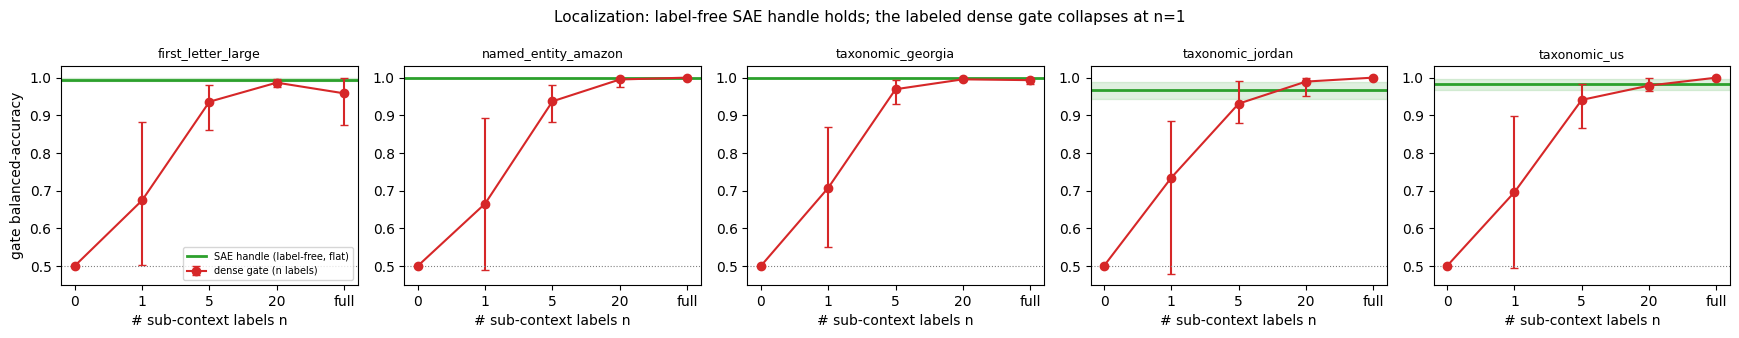

In [8]:
ncase = len(loc)
fig, axes = plt.subplots(1, ncase, figsize=(3.5 * ncase, 3.4), squeeze=False)
xs = list(range(len(NLABELS)))
for ax, (case, c) in zip(axes[0], loc.items()):
    sae = c["sae"]
    ax.axhspan(sae["ci_lo"], sae["ci_hi"], color="tab:green", alpha=0.15)
    ax.axhline(sae["value"], color="tab:green", lw=2, label="SAE handle (label-free, flat)")
    yv = np.array([c.get("dense", {}).get(n, {}).get("value", np.nan) for n in NLABELS])
    ylo = np.array([c.get("dense", {}).get(n, {}).get("ci_lo", np.nan) for n in NLABELS])
    yhi = np.array([c.get("dense", {}).get(n, {}).get("ci_hi", np.nan) for n in NLABELS])
    ax.errorbar(xs, yv, yerr=[yv - ylo, yhi - yv], marker="o", color="tab:red", capsize=3,
                label="dense gate (n labels)")
    ax.axhline(0.5, color="gray", ls=":", lw=0.8)
    ax.set_xticks(xs); ax.set_xticklabels(NLABELS)
    ax.set_title(case, fontsize=9); ax.set_xlabel("# sub-context labels n"); ax.set_ylim(0.45, 1.03)
axes[0][0].set_ylabel("gate balanced-accuracy")
axes[0][0].legend(fontsize=7, loc="lower right")
plt.suptitle("Localization: label-free SAE handle holds; the labeled dense gate collapses at n=1", fontsize=11)
plt.tight_layout(); plt.show()

## 3. Edit arm — re-compute the **primary** metric `adv_pres` from raw judge scores

This is the live computation. The `edit_per_prompt` dataset holds, for the demo case, the **raw per-prompt judge
scores** (fluency + content-preservation) for the KG-ABL handle and the dense fair gate, at each `n`. We reconstruct the
paper's primary edit metric exactly:

`adv_pres(n)` = `paired_bootstrap_diff( HM_KG , HM_fair(n) )` over the **PRES** prompts (`RETAIN` + `UNRELATED`),
where `HM = harmonic_mean(fluency, content_pres)`. A value **> 0 favours the label-free SAE handle**.

At low `n` the dense gate mis-localizes → it damages preservation on `RETAIN`/`UNRELATED` → KG (the precise label-free
handle) preserves better → `adv_pres > 0` with a CI excluding 0. At full labels the gate localizes → `adv_pres → 0`
(the reproduced iter-8 anchor). *(The mini data stores the representative resample, so values track the published
K-averaged numbers very closely rather than bit-exactly.)*

In [9]:
edit_ds = next(d for d in data["datasets"] if d["dataset"] == "edit_per_prompt")["examples"]
pub_edit = data["metadata"]["curves"][DEMO_EDIT_CASE]["edit_joint_adv"]["dense"]
EDIT_NS = [n for n in N_GRID if n != 0]   # [1, 5, 20, "full"]

print(f"adv_pres for case '{DEMO_EDIT_CASE}'  (KG-ABL minus dense fair gate; >0 favours label-free SAE handle)\n")
print(f"{'n':>5}{'pairs':>7}{'adv_pres(recomp)':>18}{'CI':>20}{'excl0':>8}{'published':>11}")
print("-" * 69)
recomp = {}
for n in EDIT_NS:
    rows = [e for e in edit_ds if str(e["metadata_n"]) == str(n) and e["metadata_role"] in PRES]
    hmk, hmf = [], []
    for e in rows:
        fk = e["metadata_judge_primary_fluency_kg"];   ck = e["metadata_judge_primary_content_pres_kg"]
        ff = e["metadata_judge_primary_fluency_fair"]; cf = e["metadata_judge_primary_content_pres_fair"]
        if None in (fk, ck, ff, cf):
            continue
        hmk.append(harmonic_mean(fk, ck))      # KG-ABL preservation joint
        hmf.append(harmonic_mean(ff, cf))      # dense fair-gate preservation joint
    r = paired_bootstrap_diff(hmk, hmf)
    recomp[str(n)] = r
    pub = pub_edit[str(n)]["adv_pres_diff"]
    ci = f"[{r['ci_lo']:+.3f},{r['ci_hi']:+.3f}]"
    print(f"{str(n):>5}{r['n']:>7}{r['diff']:>+18.4f}{ci:>20}{str(r['excl_0']):>8}{pub:>+11.4f}")

adv_pres for case 'first_letter_large'  (KG-ABL minus dense fair gate; >0 favours label-free SAE handle)

    n  pairs  adv_pres(recomp)                  CI   excl0  published
---------------------------------------------------------------------
    1     16           +0.7500     [+0.458,+1.062]    True    +0.8073
    5     16           +0.1250     [+0.000,+0.375]   False    +0.0833
   20     16           +0.0417     [+0.000,+0.125]   False    +0.0312
 full     16           +0.0000     [+0.000,+0.000]   False    +0.0000


## 4. Results — fork verdict, breakeven, and the honest caveat

We assemble the reproduced verdict: the overall fork, per-arm tallies, the `n_breakeven` (smallest `n` at which the
dense gate matches the SAE handle = labels saved), the reproduced iter-8 anchor, a worked example of the KG vs fair vs
no-op continuations, and the populated honest caveat.

OVERALL FORK VERDICT : DEMONSTRATED_WHERE_TO_GATE_VALUE
per-arm verdict      : {'localization': 'DEMONSTRATED', 'edit': 'DEMONSTRATED'}
localization DEMONSTRATED : ['first_letter_large', 'named_entity_amazon', 'taxonomic_georgia', 'taxonomic_jordan', 'taxonomic_us']
edit DEMONSTRATED         : ['first_letter_large', 'named_entity_amazon']
iter-8 anchor reproduced  : adv_pres(full) CI INCLUDES 0 here (fair gate matched at full labels) — reproduced.

labels saved by the label-free SAE handle (localization n_breakeven per side):
   first_letter_large     n_breakeven=20
   named_entity_amazon    n_breakeven=20
   taxonomic_georgia      n_breakeven=20
   taxonomic_jordan       n_breakeven=5
   taxonomic_us           n_breakeven=5

HONEST CAVEAT: named_entity_amazon (edit, honest caveat): the STRICTER forget x preservation metric adv_joint stays >0 at FULL labels, but this is an INSTRUMENT-DISAGREEMENT artifact (at matched behavioral subprobe-drop forget the LLM judge still scores KG as forg

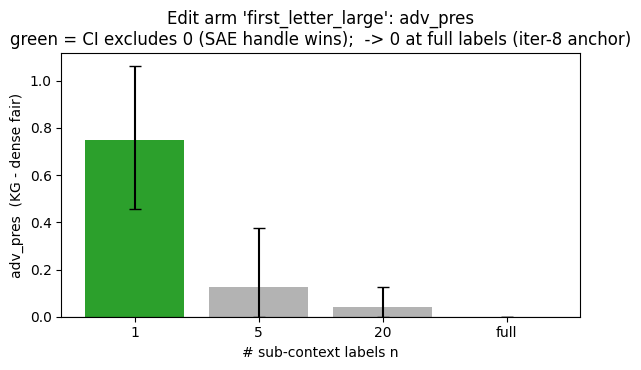

In [10]:
# ---- text summary --------------------------------------------------------
print("OVERALL FORK VERDICT :", meta["overall_fork_verdict"])
print("per-arm verdict      :", meta["per_arm_verdict"])
print("localization DEMONSTRATED :", meta["localization_tally"].get("DEMONSTRATED"))
print("edit DEMONSTRATED         :", meta["edit_tally"].get("DEMONSTRATED"))
print("iter-8 anchor reproduced  :", meta["iter8_anchor"]["note"])
print()
print("labels saved by the label-free SAE handle (localization n_breakeven per side):")
for case, c in loc.items():
    print(f"   {case:<22} n_breakeven={c['sae']['n_breakeven']}")
print()
for neg in meta["honest_negatives"]:
    print("HONEST CAVEAT:", neg[:280], "...")

# ---- worked example: KG vs fair vs no-op at n=1 (FORGET role) ------------
ex = next(e for e in edit_ds if str(e["metadata_n"]) == "1" and e["metadata_role"] == "FORGET")
print("\nExample continuation (n=1, FORGET):")
print("  prompt  :", ex["input"][:150])
print("  KG-ABL  :", ex["predict_kg_abl"][:130])
print("  fair n=1:", ex["predict_dense_sub_gated_fair_n"][:130])
print("  NOOP    :", ex["predict_noop"][:130])

# ---- bar chart: recomputed adv_pres vs n --------------------------------
ns = [str(n) for n in EDIT_NS]
diffs = [recomp[n]["diff"] for n in ns]
yerr_lo = [max(0.0, recomp[n]["diff"] - recomp[n]["ci_lo"]) for n in ns]
yerr_hi = [max(0.0, recomp[n]["ci_hi"] - recomp[n]["diff"]) for n in ns]
colors = ["tab:green" if recomp[n]["excl_0"] else "0.7" for n in ns]
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.bar(ns, diffs, yerr=[yerr_lo, yerr_hi], color=colors, capsize=4)
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("# sub-context labels n"); ax.set_ylabel("adv_pres  (KG - dense fair)")
ax.set_title(f"Edit arm '{DEMO_EDIT_CASE}': adv_pres\n"
             "green = CI excludes 0 (SAE handle wins);  -> 0 at full labels (iter-8 anchor)")
plt.tight_layout(); plt.show()